In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score

# 1. 加载 MNIST 数据集
print("✅ Loading MNIST dataset...")
mnist = fetch_openml('mnist_784', version=1)
X = mnist.data.astype('float64') / 255.0  # 归一化
y = mnist.target.astype('int')

# 可选：取较小子集以加快实验速度
X_small = X[:10000]
y_small = y[:10000]

print("Data shape:", X_small.shape)
print("Label shape:", y_small.shape)

✅ Loading MNIST dataset...
Data shape: (10000, 784)
Label shape: (10000,)


In [19]:
# 2. 初始化并训练模型
k = 10  # 聚成10类（因为有10个数字）
print(f"🚀 Running KMeans with K={k} ...")
kmeans = KMeans( n_clusters=k, n_init=10, max_iter=300, random_state=42)
kmeans.fit(X_small)

# 获取结果
labels = kmeans.labels_
centers = kmeans.cluster_centers_

🚀 Running KMeans with K=10 ...


In [22]:
#Step 4. 计算每个聚类主要代表的数字
dominant_digits = []
for i in range(k):
    cluster_labels = y_small[labels == i]
    if len(cluster_labels) > 0:
        values, counts = np.unique(cluster_labels, return_counts=True)
        dominant_digit = values[np.argmax(counts)]
        dominant_digits.append((i, dominant_digit))
    else:
        dominant_digits.append((i, -1))

# 按数字顺序排序聚类中心
sorted_clusters = sorted(dominant_digits, key=lambda x: x[1])
sorted_indices = [i for i, _ in sorted_clusters]


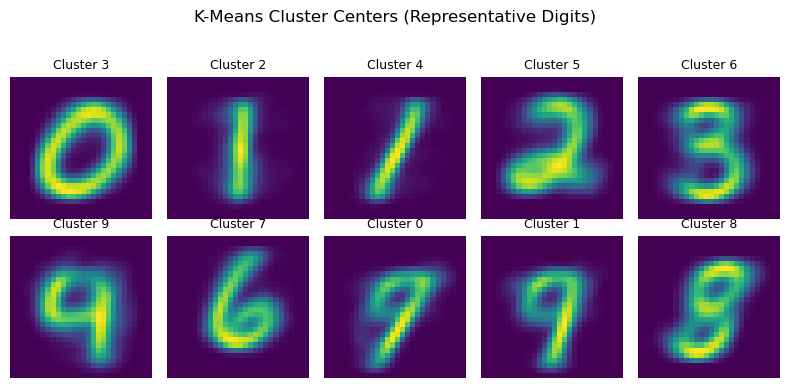

📈 Adjusted Rand Index (ARI): 0.3470


In [24]:
# Step 5. 绘制聚类中心（彩色 + 整齐排列）
fig, axes = plt.subplots(2, 5, figsize=(8, 4))
for idx, ax in zip(sorted_indices, axes.flat):
    ax.imshow(kmeans.cluster_centers_[idx].reshape(28, 28), cmap='viridis')
    ax.set_title(f'Cluster {idx}', fontsize=9)
    ax.axis('off')
plt.suptitle("K-Means Cluster Centers (Representative Digits)", fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
ari = adjusted_rand_score(y_small, labels)
print(f"📈 Adjusted Rand Index (ARI): {ari:.4f}")

📊 Plotting label distributions for each cluster...


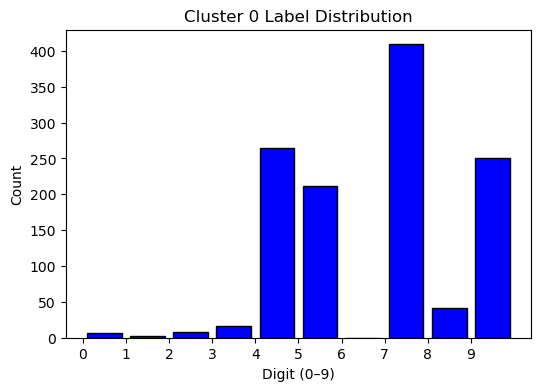

Cluster 0: mainly digit 7 (count = 409)


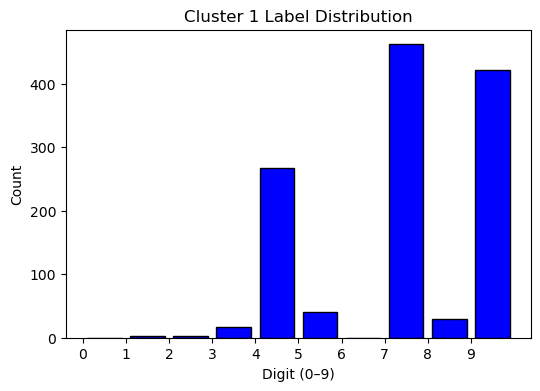

Cluster 1: mainly digit 7 (count = 462)


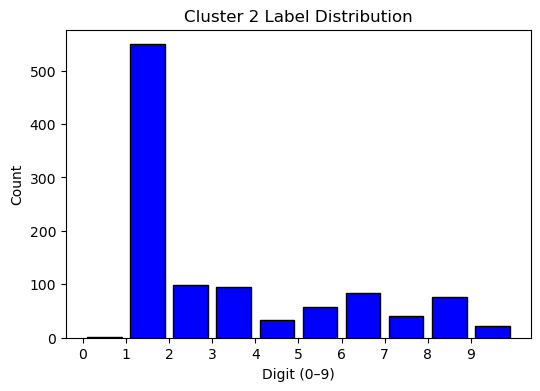

Cluster 2: mainly digit 1 (count = 549)


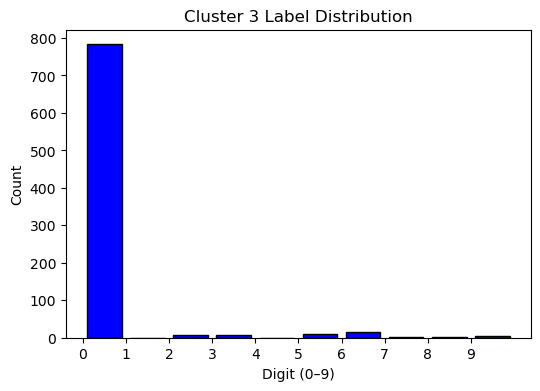

Cluster 3: mainly digit 0 (count = 783)


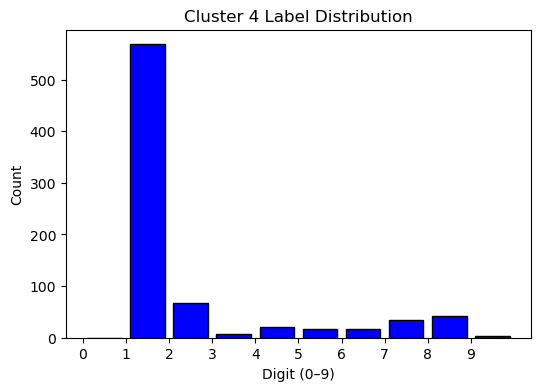

Cluster 4: mainly digit 1 (count = 568)


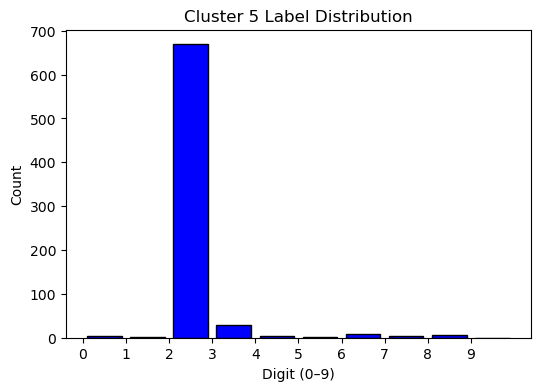

Cluster 5: mainly digit 2 (count = 669)


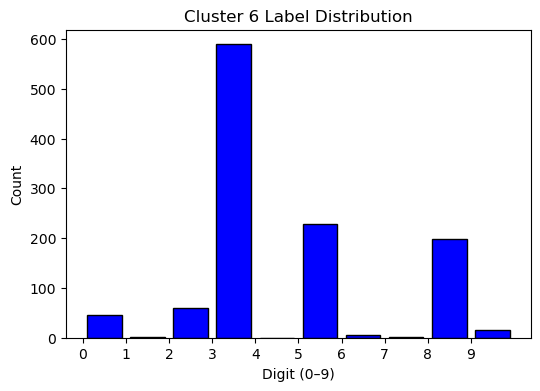

Cluster 6: mainly digit 3 (count = 589)


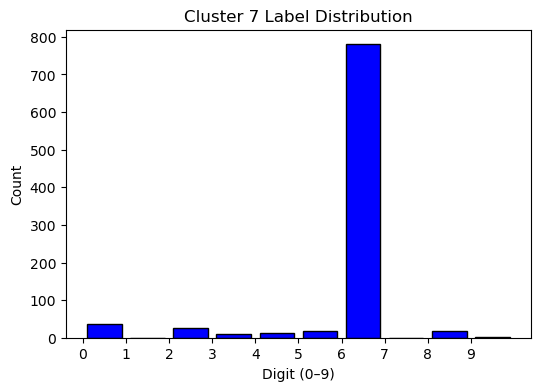

Cluster 7: mainly digit 6 (count = 780)


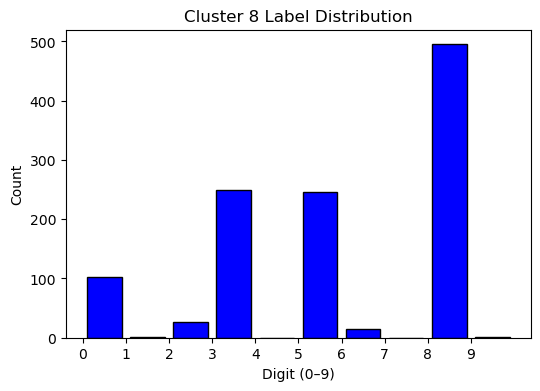

Cluster 8: mainly digit 8 (count = 495)


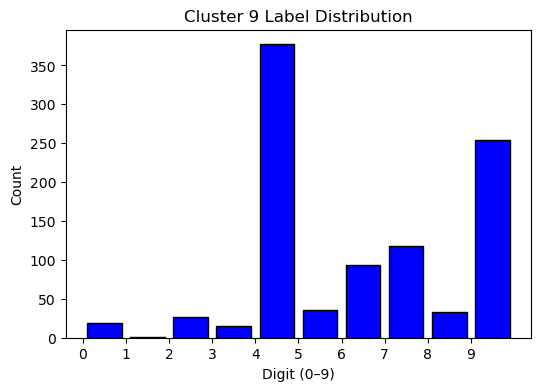

Cluster 9: mainly digit 4 (count = 377)


In [30]:
# Step 7. 绘制每个聚类对应的真实数字分布（直方图）
print("📊 Plotting label distributions for each cluster...")

for i in range(k):
    y_cluster = y_small[labels == i]
    plt.figure(figsize=(6, 4))
    plt.hist(y_cluster, bins=range(11), rwidth=0.8, color='blue', edgecolor='black')
    plt.title(f"Cluster {i} Label Distribution")
    plt.xlabel("Digit (0–9)")
    plt.ylabel("Count")
    plt.xticks(range(10))
    plt.show()

    # 输出该聚类的主要数字
    if len(y_cluster) > 0:
        values, counts = np.unique(y_cluster, return_counts=True)
        dominant_digit = values[np.argmax(counts)]
        print(f"Cluster {i}: mainly digit {dominant_digit} (count = {np.max(counts)})")
    else:
        print(f"Cluster {i}: empty cluster.")